# Path dependent options

Function initialization:

In [1]:
from QMC_option_pricing import european_call_mc, path_dependent_mc, path_dependent_at, path_dependent_cv

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
import time

def linfit(X,Y):
    logx = np.log(X)
    logY = np.log(Y)

    # linear fit: logY = a * logx + logC
    a, logC = np.polyfit(logx, logY, 1)

    C = np.exp(logC)
    return a, C

%matplotlib inline

Variable initialization:

In [2]:
S0 = 100      # spot
K = 100       # at-the-money strike
T = 1       # 1 year
r = 0.05      # 5% risk-free rate
sigma = 0.2 # 20 % volatility
rho = 0.3  # Price jump to volatility correlation
timesteps = 100
maxiter = 5
exp = 100
confidence = 0.95
bins = 100

## Path independent vs path dependent variance evolution

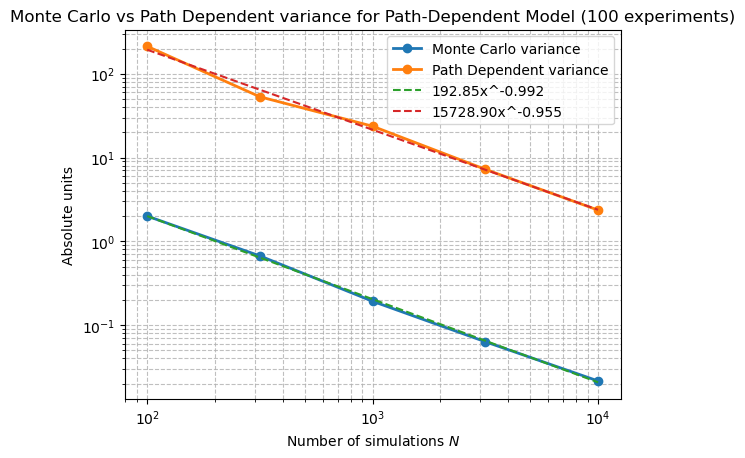

In [3]:
N = np.logspace(2, maxiter-1, maxiter, dtype=int)
MC_var = np.zeros(maxiter)
PD_var = np.zeros(maxiter)

for i, n in enumerate(N):
    prices = european_call_mc(S0, K, T, r, sigma, n, exp)
    MC_var[i] = np.var(prices, ddof=1)

    prices = path_dependent_mc(S0, K, T, r, rho, timesteps, n, exp)
    PD_var[i] = np.var(prices, ddof=1)

plt.loglog(N,MC_var,'o-',lw=2,label='Monte Carlo variance')
plt.loglog(N,PD_var,'o-',lw=2,label='Path Dependent variance')

a,C = linfit(N,MC_var)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.3f}')

a,C = linfit(N,PD_var)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.3f}')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Absolute units')
plt.title(f'Monte Carlo vs Path Dependent variance for Path-Dependent Model ({exp} experiments)')
plt.legend()
plt.show()

It can be seen that despite having the same assymptotic decrease (approximately $1/n$), the variance is much higher for this path dependent option. This is why variance reduction techniques gain even more importance for more complex models.

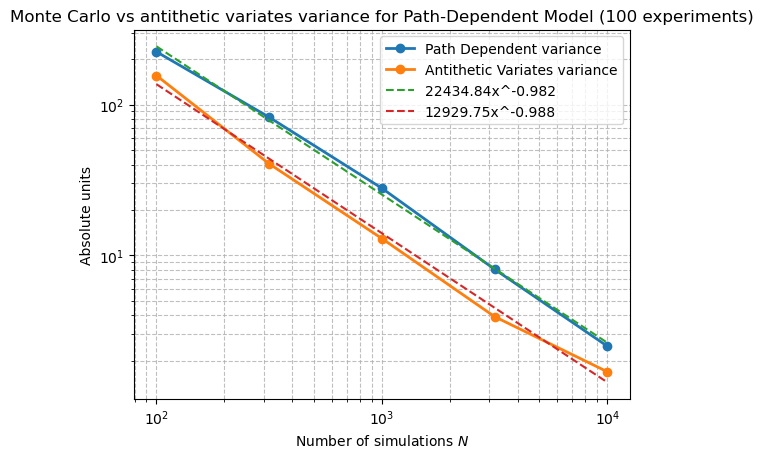

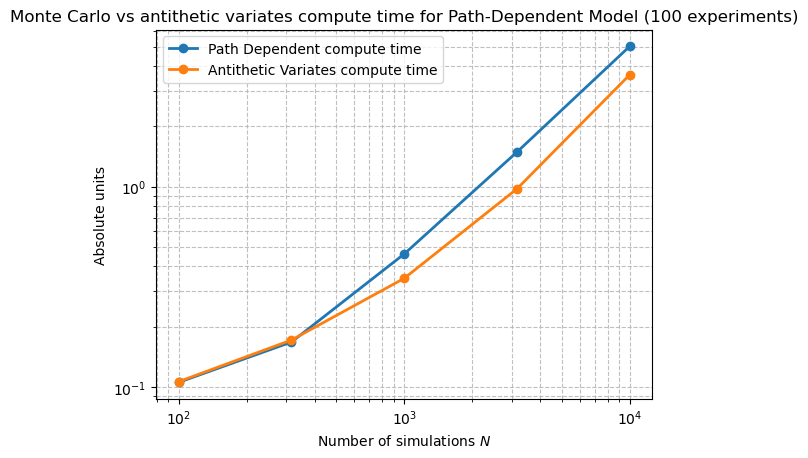

In [9]:
N = np.logspace(2, maxiter-1, maxiter, dtype=int)
PD_var = np.zeros(maxiter)
AT_var = np.zeros(maxiter)
PD_times = np.zeros(maxiter)
AT_times = np.zeros(maxiter)

for i, n in enumerate(N):
    start = time.perf_counter()
    prices = path_dependent_mc(S0, K, T, r, rho, timesteps, n, exp)
    PD_times[i] = time.perf_counter() - start
    PD_var[i] = np.var(prices, ddof=1)

    start = time.perf_counter()
    prices = path_dependent_at(S0, K, T, r, rho, timesteps, n, exp)
    AT_times[i] = time.perf_counter() - start
    AT_var[i] = np.var(prices, ddof=1)

plt.loglog(N,PD_var,'o-',lw=2,label='Path Dependent variance')
plt.loglog(N,AT_var,'o-',lw=2,label='Antithetic Variates variance')

a,C = linfit(N,PD_var)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.3f}')

a,C = linfit(N,AT_var)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.3f}')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Absolute units')
plt.title(f'Monte Carlo vs antithetic variates variance for Path-Dependent Model ({exp} experiments)')
plt.legend()
plt.show()

plt.loglog(N,PD_times,'o-',lw=2,label='Path Dependent compute time')
plt.loglog(N,AT_times,'o-',lw=2,label='Antithetic Variates compute time')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Absolute units')
plt.title(f'Monte Carlo vs antithetic variates compute time for Path-Dependent Model ({exp} experiments)')
plt.legend()
plt.show()

## Control variates

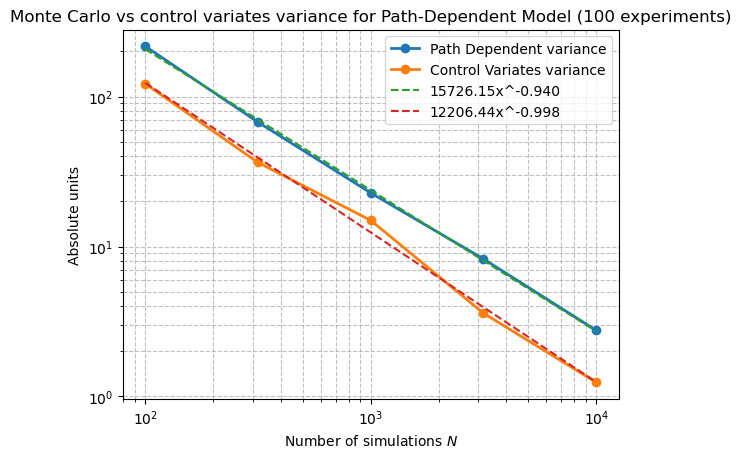

In [5]:
N = np.logspace(2, maxiter-1, maxiter, dtype=int)
PD_var = np.zeros(maxiter)
CV_var = np.zeros(maxiter)

for i, n in enumerate(N):
    prices = path_dependent_mc(S0, K, T, r, rho, timesteps, n, exp)
    PD_var[i] = np.var(prices, ddof=1)

    prices, _, _ = path_dependent_cv(S0, K, T, r, rho, timesteps, n, exp)
    CV_var[i] = np.var(prices, ddof=1)

plt.loglog(N,PD_var,'o-',lw=2,label='Path Dependent variance')
plt.loglog(N,AT_var,'o-',lw=2,label='Control Variates variance')

a,C = linfit(N,PD_var)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.3f}')

a,C = linfit(N,AT_var)
ref = C * N**a
plt.loglog(N, ref, '--', label=f'{C:.2f}x^{a:.3f}')

plt.grid(True, which="both", ls="--", alpha=0.8)
plt.xlabel('Number of simulations $N$')
plt.ylabel('Absolute units')
plt.title(f'Monte Carlo vs control variates variance for Path-Dependent Model ({exp} experiments)')
plt.legend()
plt.show()